# How To Use Varix

Varix is our implementation of a variational autoencoder.  
This tutorial follows the structure of our `Getting Started - Vanillix`, but is much less extensive, because  
our pipeline works similarly for different architectures, so here we focus only on Varix specifics.

**AUTOENCODIX** supports far more functionality than shown here, so we’ll also point to advanced tutorials where relevant.  

**IMPORTANT**

> This tutorial only shows the specifics of the Varix pipeline. If you're unfamiliar with general concepts,  
> we recommend following the `Getting Started - Vanillix` tutorial first.

## What You'll Learn

You’ll learn how to:

1. **Initialize** the pipeline and run the pipeline. <br><br>
2. Understand the Varix-specific **pipeline steps**. <br><br>
3. Access the Varix-specific **results** (mus, sigma, KL/MMD losses). <br><br>
4. **Visualize** outputs effectively. <br><br>
5. Apply **custom parameters**. <br><br>
6. **Save, load, and reuse** a trained pipeline. <br><br>

Let’s get started! 🚀


## 1) Initialize and Run Varix

We set a few custom parameters of the config file. For a deep dive into the config object, see:  

`Tutorials/DeepDives/ConfigTutorial.ipynb`

#### 1.1 The Dataset

Here, we provide a mock single-cell dataset as a `MuData` object in our custom `DataPackage` structure.


In [1]:
from autoencodix.utils.example_data import EXAMPLE_MULTI_SC
from autoencodix.configs.varix_config import VarixConfig
from autoencodix.configs.default_config import DataCase
import autoencodix as acx

# Varix has its own config class
# with an additional loss term: either Kullback-Leibler (KL) or Maximum Mean Discrepancy (MMD)
# Instead of passing a pandas DataFrame, we use a pre-defined DataPackage object directly,
# this time with single-cell data.

print("Input data:")
print(EXAMPLE_MULTI_SC)
print("-" * 50)

my_config = VarixConfig(
    learning_rate=0.001,
    epochs=50,
    checkpoint_interval=5,
    default_vae_loss="kl",  # 'kl' or 'mmd' possible
    anneal_function="logistic-mid",
    data_case=DataCase.MULTI_SINGLE_CELL,	
)

print("\nStarting Pipeline")
print("-" * 50)
varix = acx.Varix(data=EXAMPLE_MULTI_SC, config=my_config)
result = varix.run()


Input data:
multi_sc:
  multi_sc: 1000 samples × 700 features
--------------------------------------------------

Starting Pipeline
--------------------------------------------------
in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>
mudata: View of MuData object with n_obs × n_vars = 1000 × 700
  2 modalities
    rna:	1000 x 500
      obs:	'cell_type', 'batch', 'donor', 'cell_cycle'
    protein:	1000 x 200
      obs:	'cell_type', 'batch', 'donor', 'cell_cycle'
Processing 1 MuData objects: ['multi_sc']
Processing train modality: multi_sc


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Processing valid split
Processing valid modality: multi_sc
Processing test split
Processing test modality: multi_sc
Epoch 1 - Train Loss: 790.7137
Sub-losses: recon_loss: 790.7137, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 1 - Valid Loss: 672.8411
Sub-losses: recon_loss: 672.8411, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 2 - Train Loss: 728.1086
Sub-losses: recon_loss: 728.1084, var_loss: 0.0002, anneal_factor: 0.0001, effective_beta_factor: 0.0000
Epoch 2 - Valid Loss: 745.1293
Sub-losses: recon_loss: 745.1287, var_loss: 0.0006, anneal_factor: 0.0001, effective_beta_factor: 0.0000
Epoch 3 - Train Loss: 683.4781
Sub-losses: recon_loss: 683.4770, var_loss: 0.0011, anneal_factor: 0.0001, effective_beta_factor: 0.0000
Epoch 3 - Valid Loss: 635.8713
Sub-losses: recon_loss: 635.8710, var_loss: 0.0003, anneal_factor: 0.0001, effective_beta_factor: 0.0000
Epoch 4 - Train Loss: 646.3028
Sub-losses: recon_loss: 646.3015, var

## 2) Specific Varix Steps (with Beta Annealing Explanation)

The pipeline (`run`) does not have Varix-specific steps.  
It calls:
- preprocess  
- fit  
- predict  
- visualize  

However, the fit step works slightly differently because we have a second loss term for the distribution loss.  
This loss term can be weighted with a hyperparameter `beta` (set via config), and the weighting can be changed during training depending on the epoch via **beta annealing**.  

**Beta annealing** gradually increases the weight of the VAE distribution loss during training.  
For example, you might start with `beta=0` to let the reconstruction loss dominate early, and then gradually increase `beta` to 1 as training progresses.  
Different annealing strategies are supported, including logistic schedules, multi-phase linear or logarithmic schedules, and constant or no annealing.  
This allows more stable training and better latent space learning, especially for early epochs.

Since we're working with a variational autoencoder, we can call an additional pipeline step, `sample_latent_space`.  
The latent space inside the pipeline is sampled once from the fitted normal distribution, with one set of `mu` and `sigma` per latent dimension.  

By default, we sample from the trained model and the test data, but you can specify the split and epoch.

**ATTENTION**   <br><br>
> If you want to sample from a different split (uses data from that split as input) or epoch (uses the model at this epoch), you need to ensure you select an epoch that was checkpointed (see `checkpoint_interval` config parameter).


In [2]:
print(f"Annealing Strategy for training was: {my_config.anneal_function}")
print(f"beta hyperparam was set to: {my_config.beta}")
print("\n")
print("Starting sampling different latent spaces")
print("-"*50)
latent_spaces_sampled = varix.sample_latent_space(n_samples=100)
print(f"sampled latent space shape: {latent_spaces_sampled.shape}")

# or
sampled = varix.sample_latent_space(split="train", epoch=4,n_samples=50)
sampled

Annealing Strategy for training was: logistic-mid
beta hyperparam was set to: 0.1


Starting sampling different latent spaces
--------------------------------------------------
sampled latent space shape: torch.Size([100, 16])


tensor([[ 1.5427e-01,  1.7976e-01,  9.0600e-01, -1.2311e+00,  7.5307e-01,
          2.2417e-01, -6.1575e-01, -4.4496e-01,  1.6431e+00,  5.1391e-01,
         -7.4805e-01,  1.6769e+00,  1.6825e+00, -1.7009e+00, -8.5462e-02,
         -2.2010e+00],
        [ 1.1387e+00,  1.1380e+00,  1.1625e+00,  1.9993e-01, -1.5343e+00,
          1.0933e-02, -4.4286e-01, -2.1830e-01, -5.6976e-01,  1.3379e+00,
          8.4043e-01,  8.0975e-01, -2.6927e+00, -2.4548e-01,  4.3390e-01,
          7.5657e-01],
        [-2.4054e+00, -1.7570e+00,  2.2076e+00,  8.1986e-01, -1.5788e+00,
          1.4272e+00,  2.6473e-01,  2.7277e-01,  5.7368e-02, -1.3397e-01,
          2.6118e+00, -3.2190e-01,  1.0408e+00, -8.8105e-01,  3.0991e-01,
         -9.5607e-01],
        [-3.4282e-01, -1.2022e-01, -1.0633e-01,  1.8353e+00,  1.1917e+00,
         -6.0453e-01,  2.1325e+00,  1.3805e+00,  2.6157e+00,  1.2192e+00,
          1.8439e-01,  3.2983e-01, -4.7842e-01, -1.4090e+00,  3.2708e+00,
          1.2239e+00],
        [ 4.3540e-01

## 3) Inspect Varix-Specific Results

In addition to the results that the Vanillix pipeline provided, we can access:
- Fitted distribution parameters `mu` and `sigma`  
- `total`, `reconstruction`, and `vae` losses  
- `anneal_factor`  

A note on the different loss types:  
For our variational autoencoder, the total loss consists of a reconstruction loss and a distribution loss (i.e., KL-divergence).  
To investigate these losses, the `result` object has the attribute `sub_losses`.  
This is a `LossRegistry` with the name of the loss as the key, and the value is a `TrainingDynamics` object, which can be accessed in the same way as for the Vanillix results.

For more details, check `Tutorials/DeepDives/PipelineOutputTutorial.ipynb`.


In [3]:
sub_losses = result.sub_losses
print("Sub Losses:")
print(f"keys: {sub_losses.keys()}")
print("\n")
recon_dyn = sub_losses.get(key="recon_loss")
print("Value of reconstruction loss in epoch 4 for train split")
print(recon_dyn.get(split="train", epoch=4))

Sub Losses:
keys: dict_keys(['recon_loss', 'var_loss', 'anneal_factor', 'effective_beta_factor'])


Value of reconstruction loss in epoch 4 for train split
625.9371261160715


## 4) Show Visualizations

This follows the standard pipeline process and can be done by calling `show_result()`.  
We can also add the keyword argument `params` to `show_result()`, which colors the plots according to a metadata column.


Creating plots ...


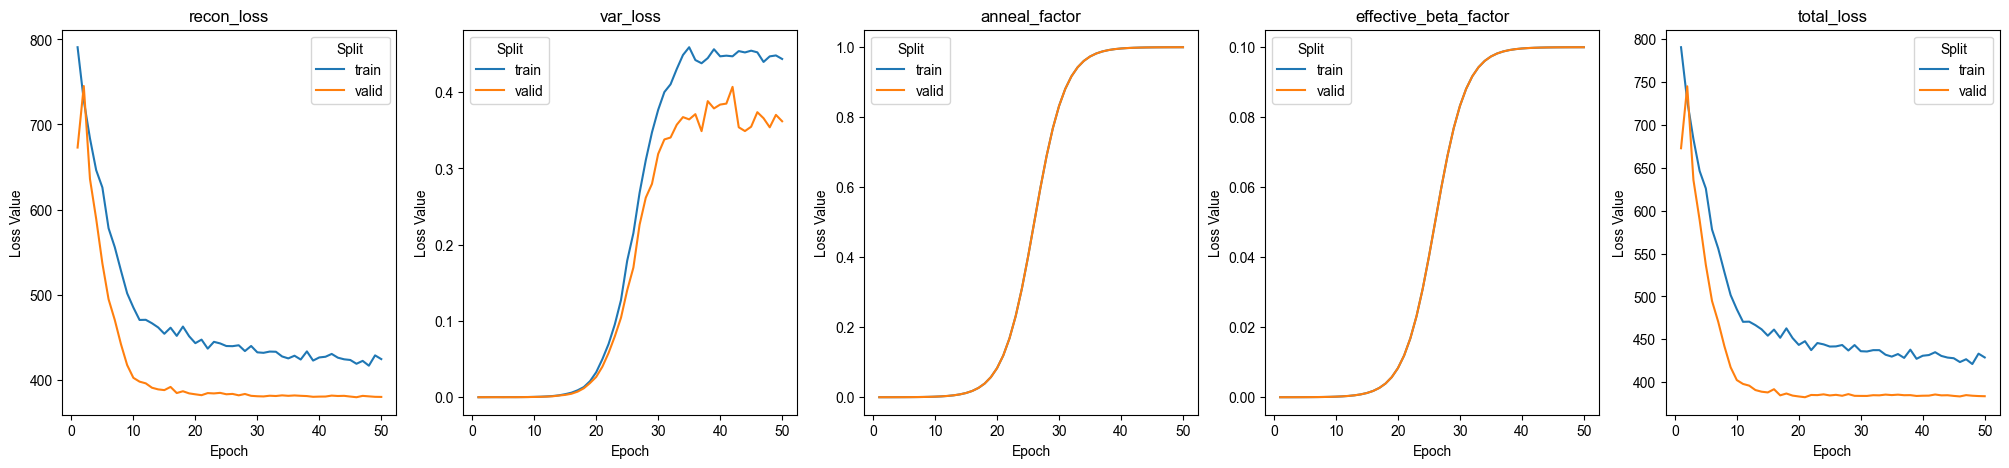

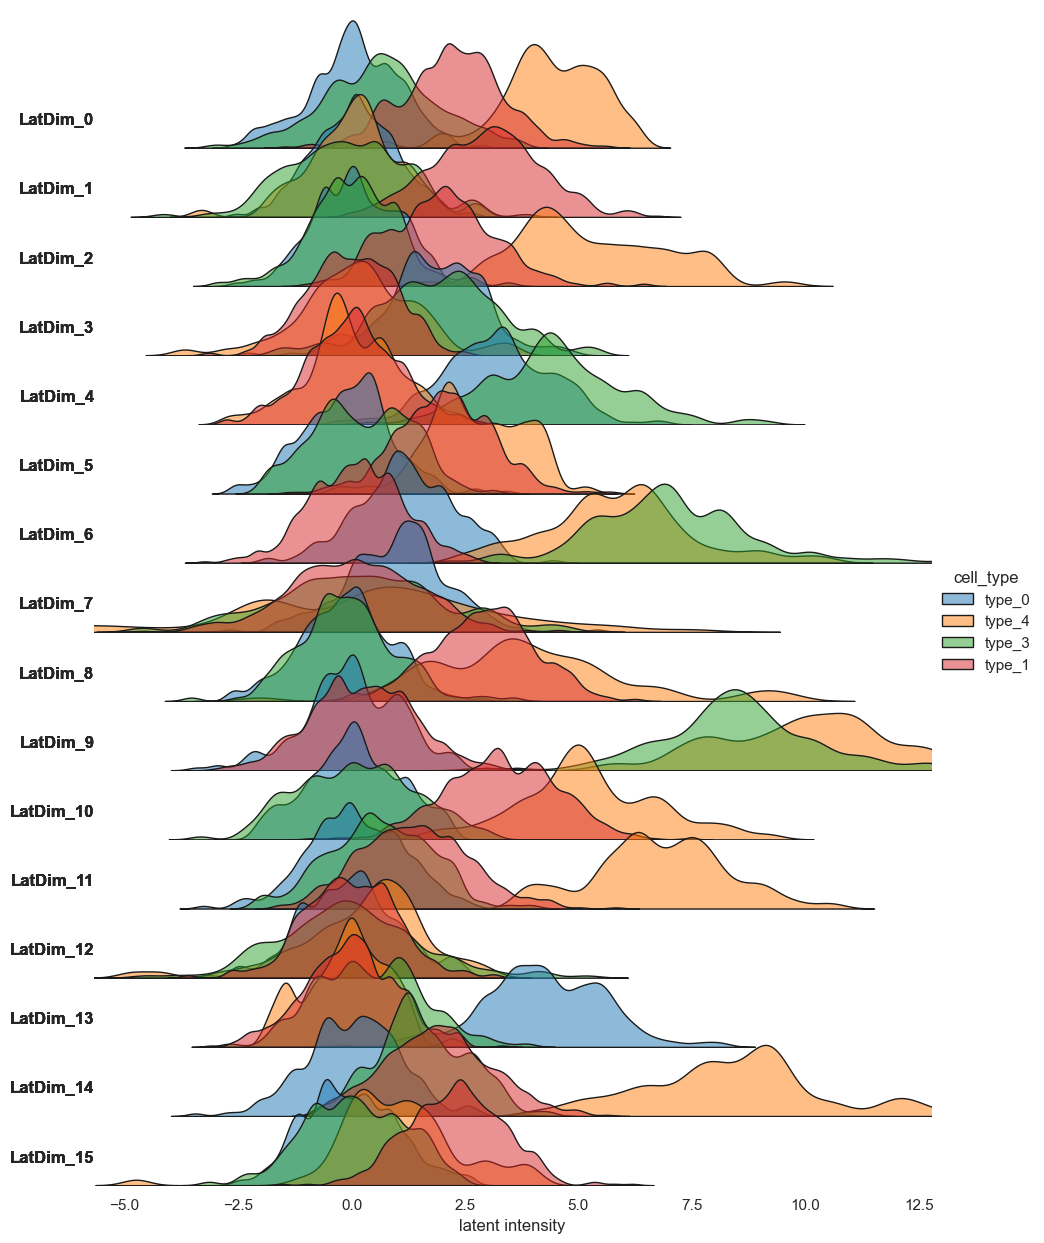

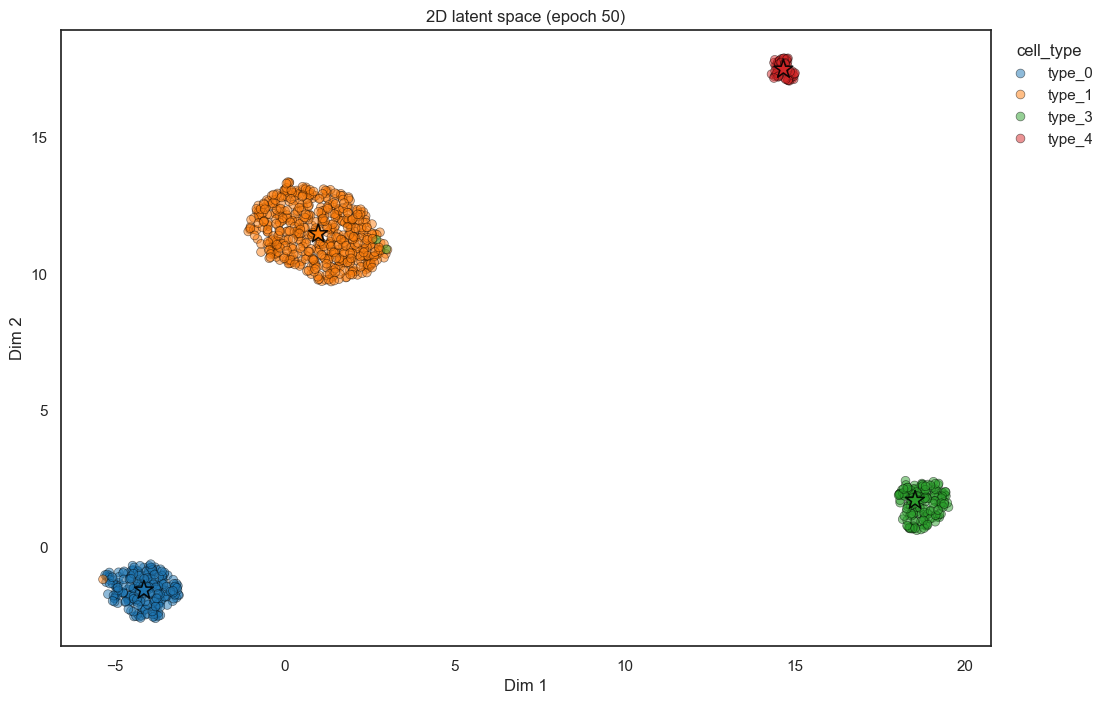

In [5]:
varix.result.datasets.test.metadata.head()

varix.show_result(params=["cell_type"])

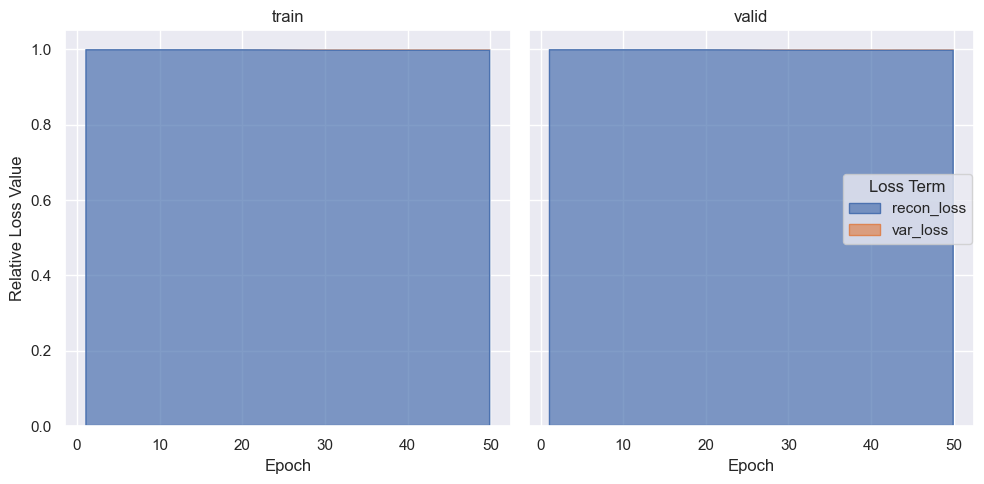

In [6]:
varix.visualizer.show_loss(plot_type="relative")

In [7]:
EXAMPLE_MULTI_SC.multi_sc["multi_sc"].obs_names

Index(['cell_0', 'cell_1', 'cell_10', 'cell_100', 'cell_101', 'cell_102',
       'cell_103', 'cell_104', 'cell_105', 'cell_106',
       ...
       'cell_990', 'cell_991', 'cell_992', 'cell_993', 'cell_994', 'cell_995',
       'cell_996', 'cell_997', 'cell_998', 'cell_999'],
      dtype='object', length=1000)

## 5) Customize Varix

To customize the behavior of our pipeline, you adjust the configuration.  
There are two ways to work with the config:

1. Create a customized instance of the config class.  
2. Provide a `yaml` file and use the config class to read it.  

We will focus on option 1 and show a few examples. For a deeper dive into configurations, please refer to `Tutorials/DeepDives/ConfigTutorial.ipynb` <br>

In this section, we demonstrate some Varix-specific parameters:
- Loss term  
- Beta  
- Annealing strategy  
- Retrieve information about all config parameters


In [8]:
from autoencodix.configs import VarixConfig
custom_config = VarixConfig(default_vae_loss="mmd", beta=1.5, anneal_function="3phase-linear", data_case=DataCase.MULTI_SINGLE_CELL, epochs=50)

custom_varix = acx.Varix(config=custom_config, data=EXAMPLE_MULTI_SC)
result = custom_varix.run()

in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>
mudata: View of MuData object with n_obs × n_vars = 1000 × 700
  2 modalities
    rna:	1000 x 500
      obs:	'cell_type', 'batch', 'donor', 'cell_cycle', 'n_genes'
    protein:	1000 x 200
      obs:	'cell_type', 'batch', 'donor', 'cell_cycle', 'n_genes'
Processing 1 MuData objects: ['multi_sc']
Processing train modality: multi_sc
Processing valid split
Processing valid modality: multi_sc
Processing test split
Processing test modality: multi_sc
Epoch 1 - Train Loss: 783.8054
Sub-losses: recon_loss: 783.8054, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 1 - Valid Loss: 824.1777
Sub-losses: recon_loss: 824.1777, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 2 - Train Loss: 704.2721
Sub-losses: recon_loss: 704.2721, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 2 - Valid Loss: 731.4035
Sub-losses: recon_loss: 

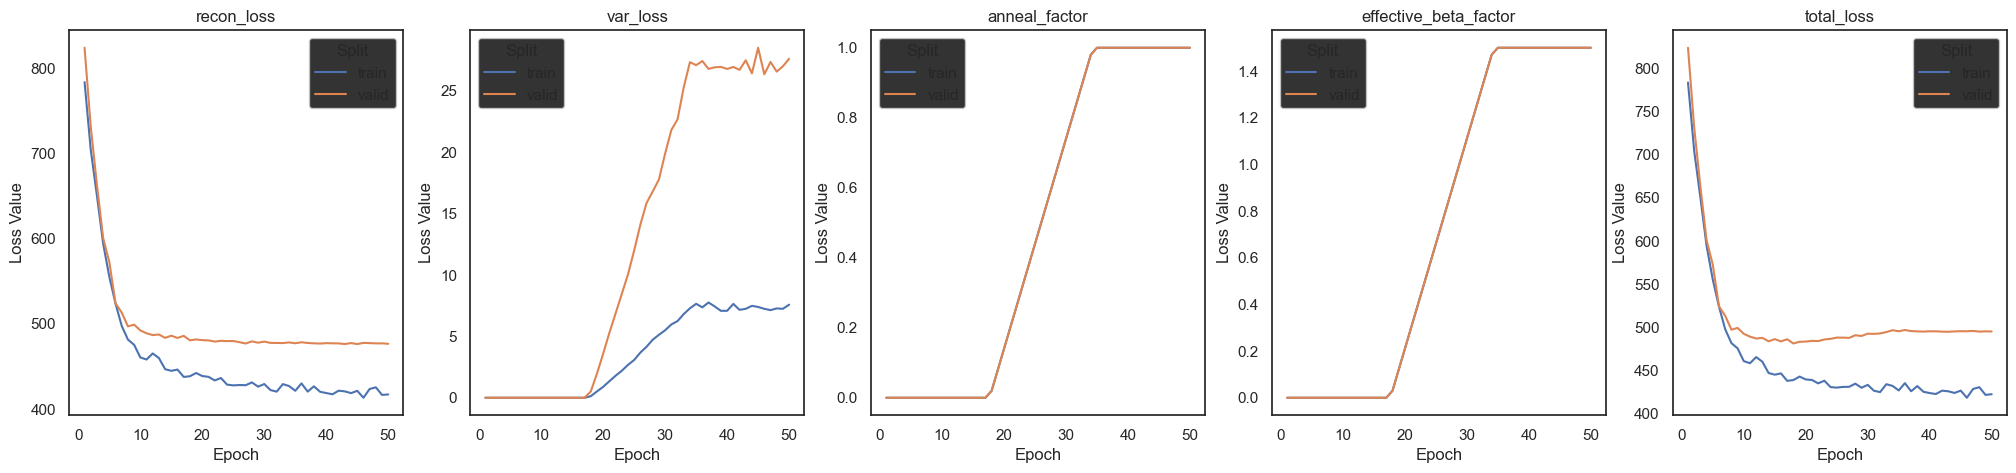

In [9]:
custom_varix.visualizer.show_loss(plot_type="absolute")

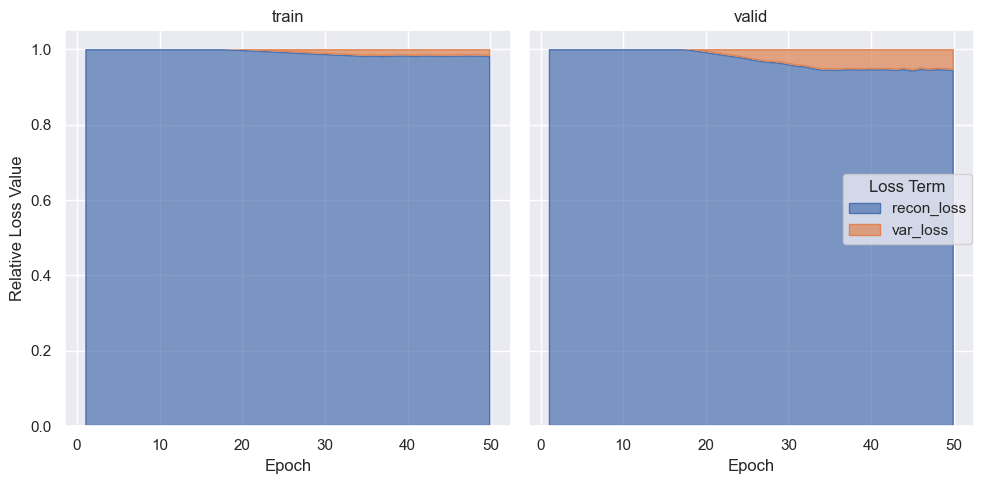

In [10]:
custom_varix.visualizer.show_loss(plot_type="relative")

## 6) Re-use, Save, Load
There are not `Varix` specific steps here. See the `Getting Started - Vanillix` for details. Below is a basic save/load usecase:

In [11]:
import os
import glob
# use a filename without extension, we handle this internally
outpath = os.path.join("tutorial_res", "varix")
varix.save(file_path=outpath, save_all=False)

folder = os.path.dirname(outpath)
pkl_files = glob.glob(os.path.join(folder, "*.pkl"))
model_files = glob.glob(os.path.join(folder, "*.pth"))

print("PKL files:", pkl_files)
print("Model files:", model_files)

# the load functionality automatically will build the pipeline object out of the three saved files
varix_loaded = acx.Varix.load(outpath)
varix_loaded.predict(data=EXAMPLE_MULTI_SC)
varix_loaded.visualize()
varix_loaded.show_result(params=["rna:cell_type"])

Preprocessor saved successfully.
saving memory efficient
Pipeline object saved successfully.
PKL files: ['tutorial_res/disent_preprocessor.pkl', 'tutorial_res/van_preprocessor.pkl', 'tutorial_res/disent.pkl', 'tutorial_res/stackix_preprocessor.pkl']
Model files: ['tutorial_res/disent_model.pth', 'tutorial_res/stackix_model.pth', 'tutorial_res/van_model.pth']
Attempting to load a pipeline from tutorial_res/varix...
Pipeline object loaded successfully. Actual type: Varix
Preprocessor loaded successfully.
in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>
mudata: View of MuData object with n_obs × n_vars = 1000 × 700
  2 modalities
    rna:	1000 x 500
      obs:	'cell_type', 'batch', 'donor', 'cell_cycle', 'n_genes'
    protein:	1000 x 200
      obs:	'cell_type', 'batch', 'donor', 'cell_cycle', 'n_genes'
Processing 1 MuData objects: ['multi_sc']
Processing test split
Processing test modality: multi_sc
n_samples in format recon: 1000
train
n_samples fr

ValueError: Length of values (256000) does not match length of index (16000)

In [ ]:
varix_loaded.evaluate(
	params=["rna:cell_type", "rna:cell_cycle"],
	split_type="CV-5",
	)

Perform ML task with feature df: Latent
Latent
Perform ML task for target parameter: rna:cell_type
Perform ML task for target parameter: rna:cell_cycle


/Users/maximilianjoas/development/autoencodix_package/src/autoencodix/utils/_result.py:346: UserWarning: We could not create visualizations for the loss plots.
This usually happens if you try to visualize after saving and loading the pipeline object with `save_all=False`. This memory-efficient saving mode does not retain past training loss data.

Original error message: tuple index out of range
  warnings.warn(
/Users/maximilianjoas/development/autoencodix_package/src/autoencodix/utils/_result.py:346: UserWarning: We could not create visualizations for the loss plots.
This usually happens if you try to visualize after saving and loading the pipeline object with `save_all=False`. This memory-efficient saving mode does not retain past training loss data.

Original error message: tuple index out of range
  warnings.warn(


Result Object Public Attributes:
------------------------------
latentspaces: TrainingDynamics object
sample_ids: TrainingDynamics object
reconstructions: TrainingDynamics object
mus: TrainingDynamics object
sigmas: TrainingDynamics object
losses: TrainingDynamics object
sub_losses: LossRegistry(_losses={})
preprocessed_data: Tensor of shape (0,)
model: VarixArchitecture
model_checkpoints: TrainingDynamics object
datasets: DatasetContainer(train=None, valid=None, test=None)
new_datasets: DatasetContainer(train=<autoencodix.data._numeric_dataset.NumericDataset object at 0x35eee2f50>, valid=None, test=<autoencodix.data._numeric_dataset.NumericDataset object at 0x35eee2b30>)
adata_latent: AnnData object with n_obs × n_vars = 1000 × 16
    uns: 'var_names'
final_reconstruction: MuData object with n_obs × n_vars = 1000 × 700
  2 modalities
    rna:	1000 x 500
      obs:	'rna:cell_type', 'rna:batch', 'rna:donor', 'rna:cell_cycle', 'rna:n_genes', 'protein:cell_type', 'protein:batch', 'protein

Showing plot for ML algorithm: LogisticRegression()


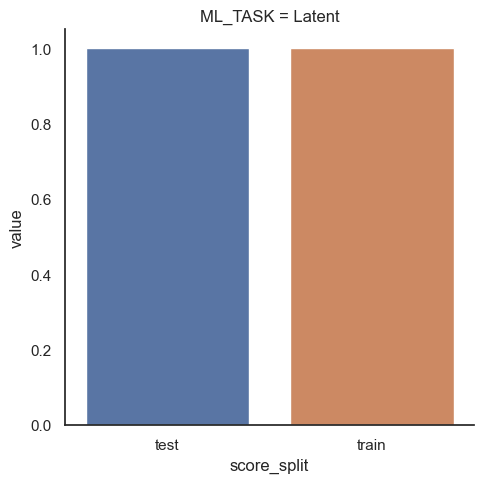

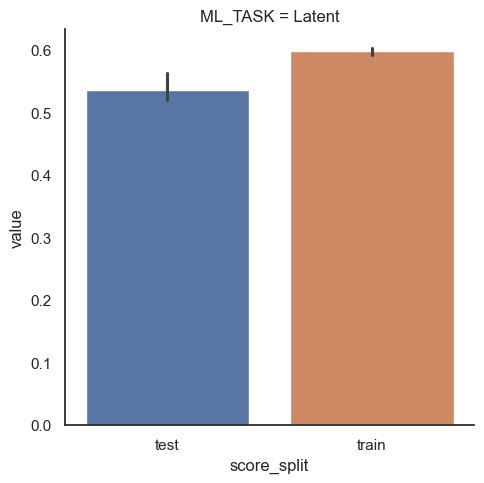

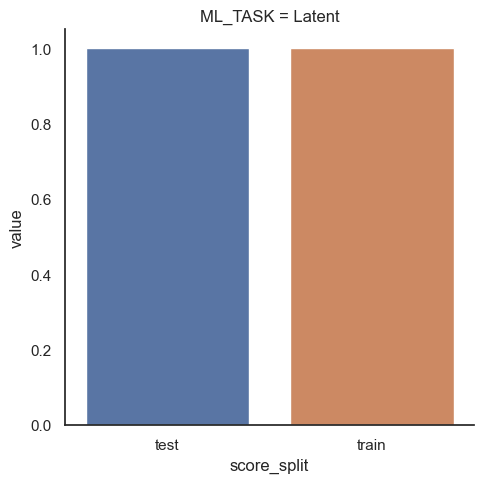

In [ ]:
varix_loaded.visualizer.show_evaluation(
	param="rna:cell_type",
	metric="roc_auc_ovo",
)